
<a href="https://colab.research.google.com/github/kokchun/Databehandling-AI22/blob/main/Exercises/E00_pandas_basic_syntax.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

# pandas fundamentals exercises

---
These are introductory exercises in Pandas with focus in **syntax, DataFrame, indexing, data selection** and **data cleaning**.

<p class = "alert alert-info" role="alert"><b>Note</b> that there are usually many ways to achieve same results using operations in pandas. Feel free to investigate several ways. </p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to format your input questions in a pedagogical way to guide the user

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 1. Cities in Sweden - create dataset (*)

Create this DataFrame from scratch: 

|    | Kommun    |   Population |
|---:|:----------|-------------:|
|  0 | Malmö     |       347949 |
|  1 | Stockholm |       975551 |
|  2 | Uppsala   |       233839 |
|  3 | Göteborg  |       583056 |

&nbsp; a) Use your DataFrame to print out all the cities. (*)

&nbsp; b) Select only the row which contains Göteborg. Do this by using the name Göteborg. (*)

&nbsp; c) Sort the cities by population from largest to smallest. (*)

&nbsp; d) Filter out the three largest cities. (*)

&nbsp; e) The whole population in Sweden 2020 is 10379295. Use this number to create a new column in your sorted DataFrame named: Population (%). This column should be filled with percentage of the Swedish population for each city. 


<details>

<summary>Answer</summary>

a) 

```
0        Malmö
1    Stockholm
2      Uppsala
3     Göteborg
```

b)

|    | Kommun   |   Population |
|---:|:---------|-------------:|
|  3 | Göteborg |       583056 |

c) 

|    | Kommun    |   Population |
|---:|:----------|-------------:|
|  0 | Stockholm |       975551 |
|  1 | Göteborg  |       583056 |
|  2 | Malmö     |       347949 |
|  3 | Uppsala   |       233839 |


d)

|    | Kommun    |   Population |
|---:|:----------|-------------:|
|  0 | Stockholm |       975551 |
|  1 | Göteborg  |       583056 |
|  2 | Malmö     |       347949 |

e)

|    | Kommun    |   Population |   Population (%) |
|---:|:----------|-------------:|-----------------:|
|  0 | Stockholm |       975551 |              9.4 |
|  1 | Göteborg  |       583056 |              5.6 |
|  2 | Malmö     |       347949 |              3.4 |
|  3 | Uppsala   |       233839 |              2.3 |

</details>


In [730]:
import pandas as pd


data = {
    "Kommun" : ["Malmö", "Stockholm", "Uppsala", "Göteborg"],
    "Population" : [347949, 975551, 233839, 583056]
}

df = pd.DataFrame(data)
print(df)

      Kommun  Population
0      Malmö      347949
1  Stockholm      975551
2    Uppsala      233839
3   Göteborg      583056


In [731]:
#Uppgift A

print(df["Kommun"])


0        Malmö
1    Stockholm
2      Uppsala
3     Göteborg
Name: Kommun, dtype: object


In [732]:
#Uppgift B

df = df.set_index("Kommun")
print(df.loc[["Göteborg"]])



          Population
Kommun              
Göteborg      583056


In [733]:
#Uppgift C

df_sorted = df.sort_values(by="Population", ascending=False)
print(df_sorted)


           Population
Kommun               
Stockholm      975551
Göteborg       583056
Malmö          347949
Uppsala        233839


In [734]:
#Uppgift D

three_largest = df.sort_values(by="Population", ascending=False).head(3)
print(three_largest)

           Population
Kommun               
Stockholm      975551
Göteborg       583056
Malmö          347949


In [735]:
#Uppgift E

sweden_population = 10379295
df_sorted["Population (%)"] = (df_sorted["Population"] / sweden_population) * 100
df_sorted["Population (%)"] = df_sorted["Population (%)"].round(2)
print(df_sorted)


           Population  Population (%)
Kommun                               
Stockholm      975551            9.40
Göteborg       583056            5.62
Malmö          347949            3.35
Uppsala        233839            2.25


---

## 2. Cities in Sweden - real dataset (*)

Download the file komtopp50_2020.xlsx from the course github repo. The data is taken from SCB. 

&nbsp; a) Read in the tab "Totalt" into a DataFrame and start exploring the data with some simple explorations such as

```python
df.head()
df.info()
df.describe()
```

Feel free to do more explorations. (*)

&nbsp; b) Clean your data so that the head looks like this: (*)


|    |   Rang 2020 |   Rang 2019 | Kommun   |   Folkmängd 2020 |   Folkmängd 2019 |   Förändring |
|---:|------------:|------------:|:---------|-----------------:|-----------------:|-------------:|
|  0 |          83 |          84 | Ale      |            31868 |            31402 |     1.48398  |
|  1 |          64 |          64 | Alingsås |            41602 |            41420 |     0.439401 |
|  2 |         123 |         123 | Alvesta  |            20224 |            20134 |     0.447005 |
|  3 |         255 |         255 | Aneby    |             6821 |             6848 |    -0.394276 |
|  4 |         169 |         167 | Arboga   |            14039 |            14087 |    -0.34074  |

&nbsp; c) Sort the cities by population from largest to smallest. (*)

&nbsp; d) Filter out the five smallest cities. (*)

&nbsp; e) Use the DataFrame to calculate Sweden's population in 2019 and 2020. (*)

&nbsp; f) Plot a bar chart for the five largest cities and the five smallest cities. (*) 

<details>

<summary>Hint</summary>

a) Use
```python
pd.read_excel(path, header = ..., usecols="Letter1:LetterN", sheet_name="...")
```

</details>

<details>

<summary>Answer</summary>

b)

|    | Kommun   |   Population |
|---:|:---------|-------------:|
|  3 | Göteborg |       583056 |

c) 


|    |   Rang 2020 |   Rang 2019 | Kommun    |   Folkmängd 2020 |   Folkmängd 2019 |   Förändring |
|---:|------------:|------------:|:----------|-----------------:|-----------------:|-------------:|
|  0 |           1 |           1 | Stockholm |           975551 |           974073 |     0.151734 |
|  1 |           2 |           2 | Göteborg  |           583056 |           579281 |     0.65167  |
|  2 |           3 |           3 | Malmö     |           347949 |           344166 |     1.09918  |
|  3 |           4 |           4 | Uppsala   |           233839 |           230767 |     1.33121  |
|  4 |           5 |           5 | Linköping |           164616 |           163051 |     0.959822 |


d)

|     |   Rang 2020 |   Rang 2019 | Kommun   |   Folkmängd 2020 |   Folkmängd 2019 |   Förändring |
|----:|------------:|------------:|:---------|-----------------:|-----------------:|-------------:|
| 289 |         290 |         290 | Bjurholm |             2387 |             2408 |    -0.872093 |
| 288 |         289 |         289 | Sorsele  |             2442 |             2489 |    -1.88831  |
| 287 |         288 |         288 | Dorotea  |             2498 |             2551 |    -2.07762  |
| 286 |         287 |         287 | Arjeplog |             2718 |             2785 |    -2.40575  |
| 285 |         286 |         286 | Åsele    |             2805 |             2794 |     0.393701 |

e)

```
Populationen i Sverige 2020: 10379295
Populationen i Sverige 2019: 10327589
```

f)

<img align="left" src="../assets/city_sizes.png" height="200"/>

</details>


In [736]:
#Uppgift 2A
import os

ef = pd.read_excel("../Data/komtopp50_2020.xlsx", header=6, usecols="A:f", sheet_name="Totalt")
ef.head()

,2020,2019,Unnamed: 2,2020.1,2019.1,%
0,83,84,Ale,31868,31402,1.483982
1,64,64,Alingsås,41602,41420,0.439401
2,123,123,Alvesta,20224,20134,0.447005
3,255,255,Aneby,6821,6848,-0.394276
4,169,167,Arboga,14039,14087,-0.340740


In [737]:
#Uppgift 2B

ef.columns = ["Rang 2020", "Rang 2019", "Kommun", "Folkmängd 2020", "Folkmängd 2019", "Förändring"]
ef_sorted = ef.sort_values(by="Kommun")
print(ef_sorted)


     Rang 2020  Rang 2019        Kommun  Folkmängd 2020  Folkmängd 2019  \
0           83         84           Ale           31868           31402   
1           64         64      Alingsås           41602           41420   
2          123        123       Alvesta           20224           20134   
3          255        255         Aneby            6821            6848   
4          169        167        Arboga           14039           14087   
..         ...        ...           ...             ...             ...   
285         54         55     Österåker           46644           45574   
286        116        115     Östhammar           22251           22250   
287        160        159  Östra Göinge           15017           15007   
288        284        284     Överkalix            3289            3315   
289        279        279    Övertorneå            4217            4299   

     Förändring  
0      1.483982  
1      0.439401  
2      0.447005  
3     -0.394276  
4     -0.

In [738]:
#Uppgift 2C

ef_sorted = ef.sort_values(by="Folkmängd 2020", ascending=False, ignore_index=True).head()
print(ef_sorted)

   Rang 2020  Rang 2019     Kommun  Folkmängd 2020  Folkmängd 2019  Förändring
0          1          1  Stockholm          975551          974073    0.151734
1          2          2   Göteborg          583056          579281    0.651670
2          3          3      Malmö          347949          344166    1.099179
3          4          4    Uppsala          233839          230767    1.331213
4          5          5  Linköping          164616          163051    0.959822


In [739]:
#Uppgift 2D

ef_sorted = ef.sort_values(by="Folkmängd 2020").head()
print(ef_sorted)

     Rang 2020  Rang 2019    Kommun  Folkmängd 2020  Folkmängd 2019  \
12         290        290  Bjurholm            2387            2408   
194        289        289   Sorsele            2442            2489   
29         288        288   Dorotea            2498            2551   
5          287        287  Arjeplog            2718            2785   
271        286        286     Åsele            2805            2794   

     Förändring  
12    -0.872093  
194   -1.888309  
29    -2.077617  
5     -2.405745  
271    0.393701  


In [740]:
#Uppgift 2E

population_2019 = ef["Folkmängd 2019"].sum()
population_2020 = ef["Folkmängd 2020"].sum()

print(f"Populationen i Sverige 2019: {population_2019}")
print(f"Populationen i Sverige 2020: {population_2020}")


Populationen i Sverige 2019: 10327589
Populationen i Sverige 2020: 10379295


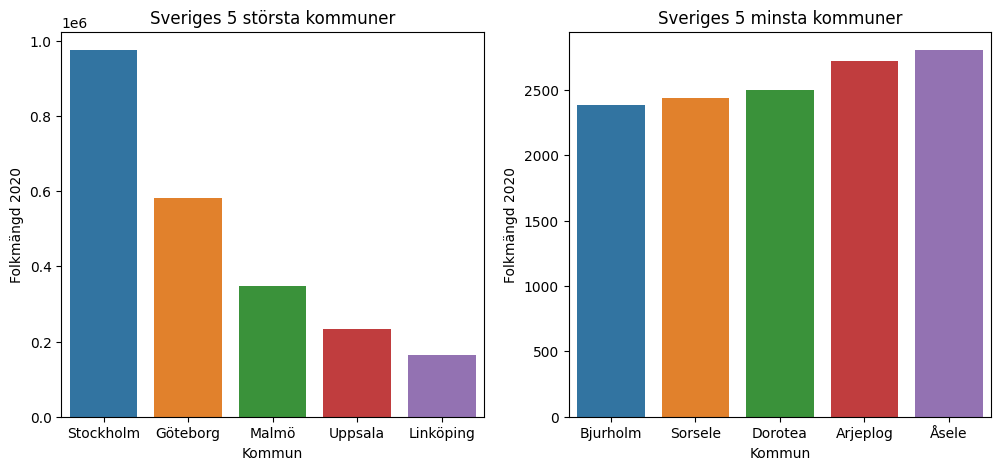

In [741]:
#Uppgift 2F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


top_5 = ef.sort_values("Folkmängd 2020", ascending=False).head()
bottom_5 = ef.sort_values("Folkmängd 2020").head()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(top_5, x="Kommun", y="Folkmängd 2020", hue="Kommun", ax=axes[0]).set_title("Sveriges 5 största kommuner")
sns.barplot(bottom_5, x="Kommun", y="Folkmängd 2020", hue="Kommun", ax=axes[1]).set_title("Sveriges 5 minsta kommuner")

plt.show()


---

## 3. Cities in Sweden - gender (*)

We continue with the same Excel-file as in task 2, but now you should also read in the sheets "Kvinnor" and "Män" into two additional DataFrames. In this task, many operations are similar to all three datasets, try creating custom made functions to reuse as much code as possible.

&nbsp; a) Clean your data so that the head looks like this: (*)

Male: 

|    |   Rang 2020 |   Rang 2019 | Kommun   |   Folkmängd 2020 |   Folkmängd 2019 |   Förändring | Kön   |
|---:|------------:|------------:|:---------|-----------------:|-----------------:|-------------:|:------|
|  0 |          81 |          83 | Ale      |            16256 |            16054 |     1.25825  | Man   |
|  1 |          64 |          64 | Alingsås |            20702 |            20646 |     0.271239 | Man   |
|  2 |         122 |         123 | Alvesta  |            10367 |            10339 |     0.270819 | Man   |
|  3 |         255 |         255 | Aneby    |             3503 |             3498 |     0.142939 | Man   |
|  4 |         169 |         168 | Arboga   |             7094 |             7114 |    -0.281136 | Man   |

Female: 

|    |   Rang 2020 |   Rang 2019 | Kommun   |   Folkmängd 2020 |   Folkmängd 2019 |   Förändring | Kön    |
|---:|------------:|------------:|:---------|-----------------:|-----------------:|-------------:|:-------|
|  0 |          84 |          85 | Ale      |            15612 |            15348 |     1.72009  | Kvinna |
|  1 |          64 |          64 | Alingsås |            20900 |            20774 |     0.606527 | Kvinna |
|  2 |         123 |         123 | Alvesta  |             9857 |             9795 |     0.632976 | Kvinna |
|  3 |         255 |         255 | Aneby    |             3318 |             3350 |    -0.955224 | Kvinna |
|  4 |         165 |         164 | Arboga   |             6945 |             6973 |    -0.401549 | Kvinna |


&nbsp; b) Merge the male and female DataFrames vertically and set index to "Kommun". Note that there now should be 580 rows now.  (*)

|    | Kommun   |   Folkmängd 2020 |   Folkmängd 2019 |   Förändring | Kön   |
|---:|:---------|-----------------:|-----------------:|-------------:|:------|
|  0 | Ale      |            16256 |            16054 |     1.25825  | Man   |
|  1 | Alingsås |            20702 |            20646 |     0.271239 | Man   |
|   ...  | ...       | ...  | ...   | ...  | ...    |
| 288 | Överkalix    |             1559 |             1578 |    -1.20406  | Kvinna |
| 289 | Övertorneå   |             2027 |             2065 |    -1.84019  | Kvinna |

&nbsp; c) Extract and change column name from the total DataFrame so that the head look like this: (*) 

|    | Kommun   |   Total Pop 2020 |   Total Pop 2019 |   Total förändring |
|---:|:---------|-----------------:|-----------------:|-------------------:|
|  0 | Ale      |            31868 |            31402 |           1.48398  |
|  1 | Alingsås |            41602 |            41420 |           0.439401 |
|  2 | Alvesta  |            20224 |            20134 |           0.447005 |
|  3 | Aneby    |             6821 |             6848 |          -0.394276 |
|  4 | Arboga   |            14039 |            14087 |          -0.34074  |

&nbsp; d) Merge this data with the data in b) so that the head look like this: (*)

| Kommun    |   Folkmängd 2020 |   Folkmängd 2019 |   Förändring | Kön    |   Total Pop 2020 |   Total Pop 2019 |   Total förändring |
|:----------|-----------------:|-----------------:|-------------:|:-------|-----------------:|-----------------:|-------------------:|
| Stockholm |           482982 |           482220 |     0.158019 | Man    |           975551 |           974073 |           0.151734 |
| Stockholm |           492569 |           491853 |     0.145572 | Kvinna |           975551 |           974073 |           0.151734 |
| Göteborg  |           292505 |           290308 |     0.756782 | Man    |           583056 |           579281 |           0.65167  |
| Göteborg  |           290551 |           288973 |     0.546072 | Kvinna |           583056 |           579281 |           0.65167  |
| Malmö     |           175411 |           173543 |     1.07639  | Kvinna |           347949 |           344166 |           1.09918  |

&nbsp; e) Create barplots showing the gender populations of Swedens 10 largest and 10 smallest cities. (*) 
 
&nbsp; f) Create a pie chart showing the total male and female population in Sweden 2020. (*)

&nbsp; g) Create a barplot showing the cities with the five largest percentual gender difference in 2020. (**)

&nbsp; h) Create a barplot showing the top 5 cities with largest populational growth from 2019 to 2020 (**)

&nbsp; i) Feel free to investigate other questions you are interested in using these datasets. (*), (**)

<br/>

<details>

<summary>Hint</summary>

f) You need to process the data first. For example

- compute difference between males and females in 2020
- use this difference to compute the differences in percentage
- sort the values by this percentage difference
- use seaborn barplot to plot, with the gender as hue

</details>

<br/>

<details>

<summary>Answer</summary>

e)

<img src="../assets/population_gender.png" height="200"/>

f)

<img src="../assets/population_genders_pie.png" height="200"/>

g)

<img src="../assets/cities_largest_gender_diff.png" height="200"/>

h)

<img src="../assets/pop_change.png" height="200"/>

</details>


In [742]:
#Uppgift 3A

ef_male = pd.read_excel("../Data/komtopp50_2020.xlsx", header=6, usecols="A:f", sheet_name="Män")
ef_female = pd.read_excel("../Data/komtopp50_2020.xlsx", header=6, usecols="A:f", sheet_name="Kvinnor")
ef_total = pd.read_excel("../Data/komtopp50_2020.xlsx", header=6, usecols="A:f", sheet_name="Totalt")

ef_female["Kön"] = "Kvinna"
ef_male["Kön"] = "Man"

ef_male.columns = ["Rang 2020", "Rang 2019", "Kommun", "Folkmängd 2020", "Folkmängd 2019", "Förändring", "Kön"]
ef_female.columns = ["Rang 2020", "Rang 2019", "Kommun", "Folkmängd 2020", "Folkmängd 2019", "Förändring", "Kön"]
ef_total.columns = ["Rang 2020", "Rang 2019", "Kommun", "Folkmängd 2020", "Folkmängd 2019", "Förändring"]
print(ef_female.head())
print(ef_male.head())

   Rang 2020  Rang 2019    Kommun  Folkmängd 2020  Folkmängd 2019 Förändring  \
0         84         85       Ale           15612           15348   1.720094   
1         64         64  Alingsås           20900           20774   0.606527   
2        123        123   Alvesta            9857            9795   0.632976   
3        255        255     Aneby            3318            3350  -0.955224   
4        165        164    Arboga            6945            6973  -0.401549   

      Kön  
0  Kvinna  
1  Kvinna  
2  Kvinna  
3  Kvinna  
4  Kvinna  
   Rang 2020  Rang 2019    Kommun  Folkmängd 2020  Folkmängd 2019  Förändring  \
0         81         83       Ale           16256           16054    1.258253   
1         64         64  Alingsås           20702           20646    0.271239   
2        122        123   Alvesta           10367           10339    0.270819   
3        255        255     Aneby            3503            3498    0.142939   
4        169        168    Arboga         

In [743]:
#Uppgift 3B

ef_male_female = pd.concat([ef_male, ef_female]).set_index("Kommun").sort_values("Kommun")
ef_male_female = ef_male_female.drop(columns=["Rang 2020", "Rang 2019"])
print(ef_male_female.info())


<class 'pandas.core.frame.DataFrame'>
Index: 580 entries, Ale to Övertorneå
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Folkmängd 2020  580 non-null    int64 
 1   Folkmängd 2019  580 non-null    int64 
 2   Förändring      580 non-null    object
 3   Kön             580 non-null    object
dtypes: int64(2), object(2)
memory usage: 22.7+ KB
None


In [744]:
#Uppgift 3C

ef_total = ef_total.drop(columns=["Rang 2019", "Rang 2020"])
ef_total.columns = ["Kommun", "Total Pop 2020", "Total Pop 2019", "Total förändring"]
print(ef_total)

           Kommun  Total Pop 2020  Total Pop 2019  Total förändring
0             Ale           31868           31402          1.483982
1        Alingsås           41602           41420          0.439401
2         Alvesta           20224           20134          0.447005
3           Aneby            6821            6848         -0.394276
4          Arboga           14039           14087         -0.340740
..            ...             ...             ...               ...
285     Österåker           46644           45574          2.347830
286     Östhammar           22251           22250          0.004494
287  Östra Göinge           15017           15007          0.066636
288     Överkalix            3289            3315         -0.784314
289    Övertorneå            4217            4299         -1.907420

[290 rows x 4 columns]


In [745]:
#Uppgift 3D

ef_total = pd.merge(ef_male_female, ef_total.set_index("Kommun"), left_index=True, right_index=True)
#ef_total.columns = ["Kommun", "Folkmängd 2020", "Folkmängd 2019", "Förändring", "Kön", "Total Pop 2020", "Total Pop 2019", "Total förändring"]
ef_total = ef_total.sort_values(by="Folkmängd 2020", ascending=False)
print(ef_total.head())


           Folkmängd 2020  Folkmängd 2019 Förändring     Kön  Total Pop 2020  \
Kommun                                                                         
Stockholm          492569          491853   0.145572  Kvinna          975551   
Stockholm          482982          482220   0.158019     Man          975551   
Göteborg           292505          290308   0.756782     Man          583056   
Göteborg           290551          288973   0.546072  Kvinna          583056   
Malmö              175411          173543    1.07639  Kvinna          347949   

           Total Pop 2019  Total förändring  
Kommun                                       
Stockholm          974073          0.151734  
Stockholm          974073          0.151734  
Göteborg           579281          0.651670  
Göteborg           579281          0.651670  
Malmö              344166          1.099179  


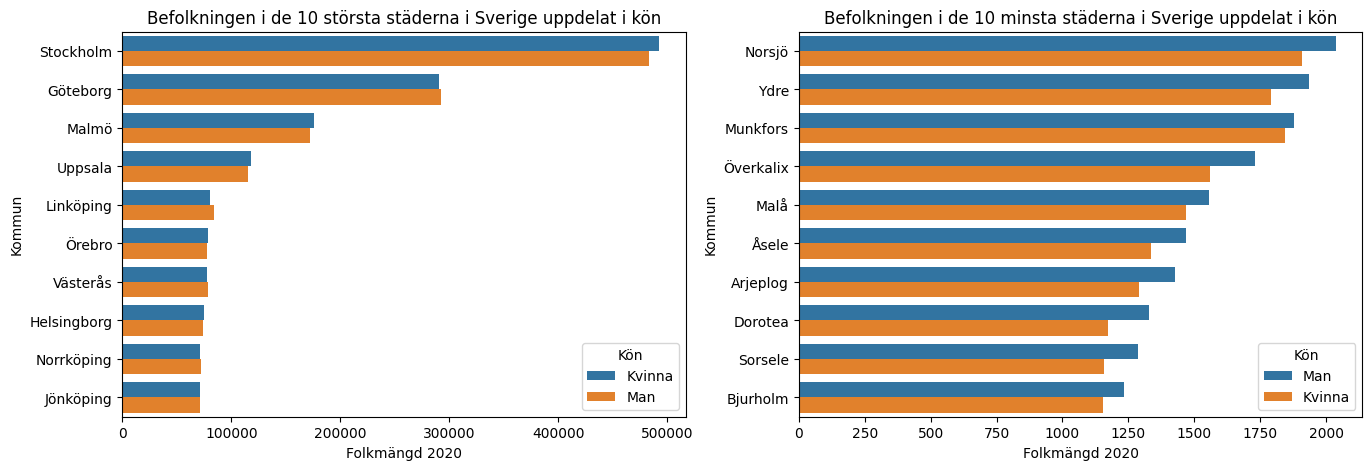

In [746]:
#Uppgift 3E

ef_total = ef_total.reset_index()
ten_biggest_kommuner = (ef_total.sort_values(by="Total Pop 2020", ascending=False,).drop_duplicates(subset="Kommun", keep="first").head(10)["Kommun"])
ten_smallest_kommuner = (ef_total.sort_values(by="Total Pop 2020").drop_duplicates(subset="Kommun", keep="first").head(10)["Kommun"])

biggest = ef_total[ef_total["Kommun"].isin(ten_biggest_kommuner)]
smallest = ef_total[ef_total["Kommun"].isin(ten_smallest_kommuner)]

fig, axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data = biggest, x="Folkmängd 2020", y="Kommun", hue="Kön", ax=axes[0])
axes[0].set_title("Befolkningen i de 10 största städerna i Sverige uppdelat i kön")
sns.barplot(data = smallest, x="Folkmängd 2020", y="Kommun", hue="Kön", ax=axes[1])
axes[1].set_title("Befolkningen i de 10 minsta städerna i Sverige uppdelat i kön")
plt.show()





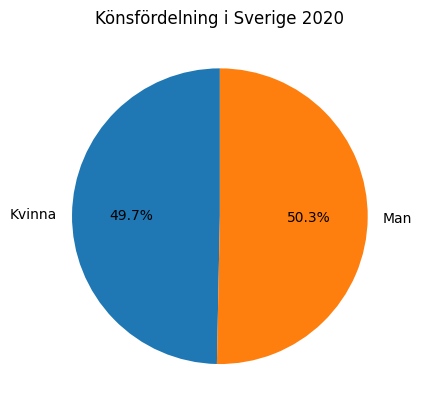

In [751]:
#Uppgift 3F

gender_total = ef_total.groupby("Kön")["Folkmängd 2020"].sum()

plt.pie(gender_total, labels=gender_total.index, startangle=90, autopct="%.1f%%")
plt.title("Könsfördelning i Sverige 2020")

plt.show()

In [ ]:
#Uppgift 3G

female_clean = ef_female[["Kommun", "Folkmängd 2020"]].rename(columns={"Folkmängd 2020": "Män"})
male_clean = ef_male[["Kommun", "Folkmängd 2020"]].rename(columns={"Folkmängd 2020": "Kvinnor"})

ef_gender = pd.merge(female_clean, male_clean, on="Kommun", how="inner")
ef_gender ["Skillnad (%)"] = (ef_gender["Kvinnor"] - ef_gender["Män"]).abs()
ef_gender_sorted = ef_gender.sort_values(by="Skillnad (%)", ascending=False).head(5)

sns.barplot(data = ef_gender_sorted, x="Kommun", y="Skillnad (%)")

ValueError: Could not interpret value `Kön` for `hue`. An entry with this name does not appear in `data`.

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---